# Hughes et al. (2026) Figure 1 reproduction

This notebook uses the same FaIR parameter as the Hughes et al. 2026 pulse experiment:

- FaIR v2.2.4
- 841-member calibrated constrained v1.4.1 ensemble
- v1.4.0 methane lifetime modification
- SSP1-2.6 baseline
- `ch4_method="Thornhill2021"`
- 2030 pulse
- +1 Gt CO2
- −12.3 Mt CH4 mitigation
- temperature perturbation calculated member-by-member relative to the corresponding SSP1-2.6 baseline member

### Important methane lifetime modification

Hughes et al. state that the overall ensemble uses calibration v1.4.1, but the CH4 response uses the v1.4.0 values for CH4 lifetime and it's sensitivities to temp and chemistry. The v1.4.1 CH4 lifetime parameters were used to match the emissions inventory to atmospheric observations, resulting in an unrealistically long CH4 lifetime. 

The notebook loads the official v1.4.0 `CH4_lifetime.csv` from the FaIR calibration archive and overwrites those methane-lifetime settings after the v1.4.1 calibration has been loaded.

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties

## 1. Files and experiment settings

In [108]:
FAIR_PARAMS_141 = "../timeseries-data/input-data/fair/calibrated_constrained_parameters_calibration1.4.1.csv"
FAIR_SPECIES_141 = "../timeseries-data/input-data/fair/species_configs_properties_calibration1.4.1.csv"

# official fair-calibrate v1.4.0 methane-lifetime file
CH4_LIFETIME_140_URL = "https://zenodo.org/records/10566646/files/CH4_lifetime.csv?download=1"

BASELINE = "ssp126"
PULSE_YEAR = 2030
CO2_PULSE_GT = 1.0
CH4_MITIGATION_MT = -12.3

START_YEAR = 1750
END_YEAR = 2200

## 2. Load the full SSP1-2.6 baseline

The earlier test notebook used only a few species. That is not appropriate here because the methane-lifetime formulation depends on background chemically reactive species. This version uses the complete FaIR species list and full RCMIP SSP1-2.6 background.

In [109]:
f_base = FAIR(ch4_method="Thornhill2021")
f_base.define_time(START_YEAR, END_YEAR, 1)
f_base.define_scenarios([BASELINE])
f_base.define_configs(["central"])

species, properties = read_properties(filename=FAIR_SPECIES_141)
f_base.define_species(species, properties)
f_base.allocate()
f_base.fill_species_configs(FAIR_SPECIES_141)
f_base.fill_from_rcmip()

print(f"{len(species)} species loaded.")
print(species)

61 species loaded.
['CO2 FFI', 'CO2 AFOLU', 'CO2', 'CH4', 'N2O', 'Sulfur', 'BC', 'OC', 'NH3', 'NOx', 'VOC', 'CO', 'CFC-11', 'CFC-12', 'CFC-113', 'CFC-114', 'CFC-115', 'HCFC-22', 'HCFC-141b', 'HCFC-142b', 'CCl4', 'CHCl3', 'CH2Cl2', 'CH3Cl', 'CH3CCl3', 'CH3Br', 'Halon-1211', 'Halon-1301', 'Halon-2402', 'CF4', 'C2F6', 'C3F8', 'c-C4F8', 'C4F10', 'C5F12', 'C6F14', 'C7F16', 'C8F18', 'NF3', 'SF6', 'SO2F2', 'HFC-125', 'HFC-134a', 'HFC-143a', 'HFC-152a', 'HFC-227ea', 'HFC-23', 'HFC-236fa', 'HFC-245fa', 'HFC-32', 'HFC-365mfc', 'HFC-4310mee', 'Solar', 'Volcanic', 'Aerosol-radiation interactions', 'Aerosol-cloud interactions', 'Ozone', 'Light absorbing particles on snow and ice', 'Stratospheric water vapour', 'Land use', 'Equivalent effective stratospheric chlorine']


## 3. Set up the 841-member v1.4.1 ensemble

In [110]:
df_configs = pd.read_csv(FAIR_PARAMS_141, index_col=0)
configs = df_configs.index
scenarios = [BASELINE, "co2_pulse", "ch4_mitigation", "net"]

f = FAIR(ch4_method="Thornhill2021")
f.define_time(START_YEAR, END_YEAR, 1)
f.define_scenarios(scenarios)
f.define_configs(configs)
f.define_species(species, properties)
f.allocate()

# load v1.4.1 defaults and 841 calibrated parameter sets
f.fill_species_configs(FAIR_SPECIES_141)
f.override_defaults(FAIR_PARAMS_141)

fill(f.climate_configs["stochastic_run"], False)
fill(f.climate_configs["use_seed"], False)

print(f"{len(configs)} calibrated ensemble members.")

841 calibrated ensemble members.


## 4. Apply the methane-lifetime parameterization

The CARB experiments retain calibration **v1.4.1** for the ensemble overall but replace the methane-lifetime terms with the full **v1.4.0** set. This avoids the much longer v1.4.1 methane lifetime while retaining the calibrated v1.4.1 climate and carbon-cycle ensemble.

The override includes the v1.4.0 unperturbed lifetime, temperature sensitivity, and chemical sensitivities to CH4, N2O, halocarbons (HC/EESC), NOx, and VOC.


In [111]:
# use the full v1.4.0 methane lifetime calibration, matching the CARB experiments
ch4_v140 = pd.read_csv(CH4_LIFETIME_140_URL).iloc[0]

fill(f.species_configs["unperturbed_lifetime"], ch4_v140["base"], specie="CH4")
fill(f.species_configs["lifetime_temperature_sensitivity"], ch4_v140["temp"])
#fill(f.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["CH4"], specie="CH4") # Currently left out because not included in Hughes
fill(f.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["N2O"], specie="N2O")
fill(f.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["HC"], specie="Equivalent effective stratospheric chlorine")
fill(f.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["NOx"], specie="NOx")
fill(f.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["VOC"], specie="VOC")

print(f"v1.4.0 CH4 base lifetime applied: {ch4_v140['base']:.3f} yr")


v1.4.0 CH4 base lifetime applied: 10.007 yr


## 5. Copy SSP1-2.6 into every scenario and add the 2030 perturbations

For each scenario, the complete SSP1-2.6 emissions, concentrations, and prescribed forcings are copied into all 841 configurations. We then change only CO2 and/or CH4 in 2030.

In [112]:
# copy the complete SSP1-2.6 background into every scenario/config
base_emissions = f_base.emissions.sel(scenario=BASELINE, config="central").values
base_concentration = f_base.concentration.sel(scenario=BASELINE, config="central").values
base_forcing = f_base.forcing.sel(scenario=BASELINE, config="central").values

for scen in scenarios:
    f.emissions.loc[dict(scenario=scen)].values[:] = base_emissions[:, None, :]
    f.concentration.loc[dict(scenario=scen)].values[:] = base_concentration[:, None, :]
    f.forcing.loc[dict(scenario=scen)].values[:] = base_forcing[:, None, :]

# apply the calibrated forcing scale factors to prescribed solar and volcanic forcing
for sp in ["Solar", "Volcanic"]:
    col = f"forcing_scale[{sp}]"
    if sp in species and col in df_configs.columns:
        original = f.forcing.sel(specie=sp).values.copy()
        scales = df_configs[col].values
        f.forcing.loc[dict(specie=sp)].values[:] = original * scales[None, None, :]

timepoints = np.asarray(f.timepoints, dtype=float)
pulse_time = timepoints[np.argmin(np.abs(timepoints - PULSE_YEAR))]
print("FaIR pulse timepoint:", pulse_time)

# +1 Gt CO2 pulse
f.emissions.loc[dict(timepoints=pulse_time, scenario="co2_pulse", specie="CO2 FFI")].values += CO2_PULSE_GT
# -12.3 Mt CH4 mitigation pulse
f.emissions.loc[dict(timepoints=pulse_time, scenario="ch4_mitigation", specie="CH4")].values += CH4_MITIGATION_MT
# combined Hughes experiment
f.emissions.loc[dict(timepoints=pulse_time, scenario="net", specie="CO2 FFI")].values += CO2_PULSE_GT
f.emissions.loc[dict(timepoints=pulse_time, scenario="net", specie="CH4")].values += CH4_MITIGATION_MT

FaIR pulse timepoint: 2029.5


## 6. Initialise and run FaIR

In [113]:
initialise(f.concentration, f.species_configs["baseline_concentration"])
initialise(f.forcing, 0.0)
initialise(f.temperature, 0.0)
initialise(f.cumulative_emissions, 0.0)
initialise(f.airborne_emissions, 0.0)
initialise(f.ocean_heat_content_change, 0.0)

# restore the prescribed SSP solar/volcanic forcing after initialization
for scen in scenarios:
    for sp in ["Solar", "Volcanic"]:
        if sp in species:
            base = f_base.forcing.sel(scenario=BASELINE, config="central", specie=sp).values[:, None]
            scale_col = f"forcing_scale[{sp}]"
            scales = df_configs[scale_col].values if scale_col in df_configs.columns else np.ones(len(configs))
            f.forcing.loc[dict(scenario=scen, specie=sp)].values[:] = base * scales[None, :]

f.run(progress=True)

Running 3364 projections in parallel: 100%|█| 450/450 [00:13<00:00, 33.56timeste


## 7. Calculate member-paired temperature perturbations

In [114]:
baseline_T = f.temperature.sel(scenario=BASELINE, layer=0)

dT_co2 = f.temperature.sel(scenario="co2_pulse", layer=0) - baseline_T
dT_ch4 = f.temperature.sel(scenario="ch4_mitigation", layer=0) - baseline_T
dT_net = f.temperature.sel(scenario="net", layer=0) - baseline_T

years = np.asarray(f.timebounds, dtype=float)
plot_years = years + 1
mask = plot_years >= 2028

net_p50 = dT_net.median(dim="config").values
net_p05 = dT_net.quantile(0.05, dim="config").values
net_p95 = dT_net.quantile(0.95, dim="config").values
co2_p50 = dT_co2.median(dim="config").values
ch4_p50 = dT_ch4.median(dim="config").values

# define crossover year calculation
def crossover_year(x, y, start=2030):
    m = x >= start
    xx, yy = x[m], y[m]
    for i in range(1, len(yy)):
        if yy[i-1] < 0 <= yy[i]:
            return xx[i-1] + (0 - yy[i-1]) * (xx[i] - xx[i-1]) / (yy[i] - yy[i-1])
    return np.nan

cross = crossover_year(plot_years, net_p50)
imin = np.nanargmin(net_p50[plot_years >= PULSE_YEAR])
post_years = years[plot_years >= PULSE_YEAR]
post_net = net_p50[plot_years >= PULSE_YEAR]

print(f"Median crossover year: {cross:.1f}")
print(f"Median peak cooling: {post_net[imin]*1e3:.3f} × 10⁻³ K in {post_years[imin]:.0f}")

Median crossover year: 2046.9
Median peak cooling: -0.308 × 10⁻³ K in 2033


## 8. Plot Hughes-style result

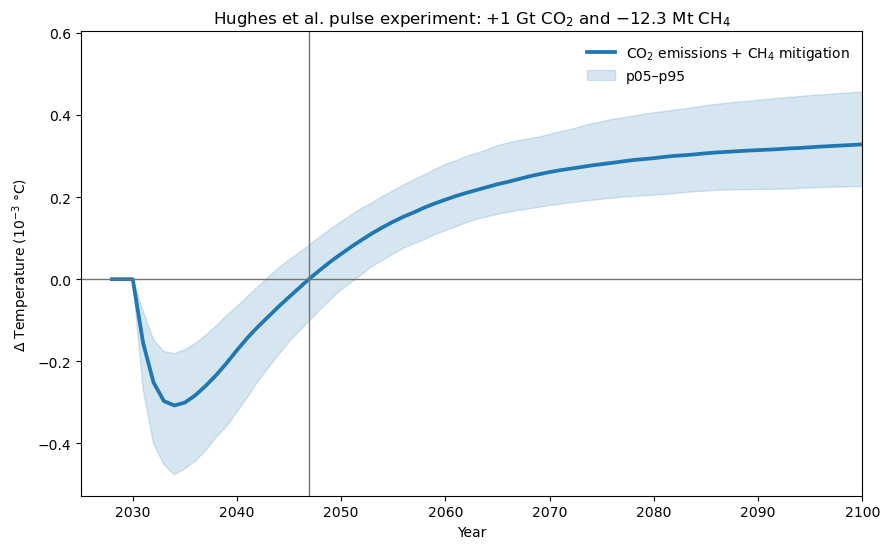

In [115]:
fig, ax = plt.subplots(figsize=(9, 5.6))

x = plot_years[mask]
y = net_p50[mask] * 1e3
lo = net_p05[mask] * 1e3
hi = net_p95[mask] * 1e3

line, = ax.plot(x, y, linewidth=2.7, label="CO$_2$ emissions + CH$_4$ mitigation")
ax.fill_between(x, lo, hi, color=line.get_color(), alpha=0.18, label="p05–p95")

ax.axhline(0, color="0.45", linewidth=1)
if np.isfinite(cross):
    ax.axvline(cross, color="0.45", linewidth=1)

ax.set_xlim(2025, 2100)
ax.set_xlabel("Year")
ax.set_ylabel("Δ Temperature ($10^{-3}$ °C)")
ax.set_title("Hughes et al. pulse experiment: +1 Gt CO$_2$ and −12.3 Mt CH$_4$")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 9. Diagnostic plot: separate CO₂ and CH₄ responses

This is not part of Hughes Figure 1, but it is useful for checking whether an unexpected result comes from the CO₂ pulse or the CH₄ mitigation response.

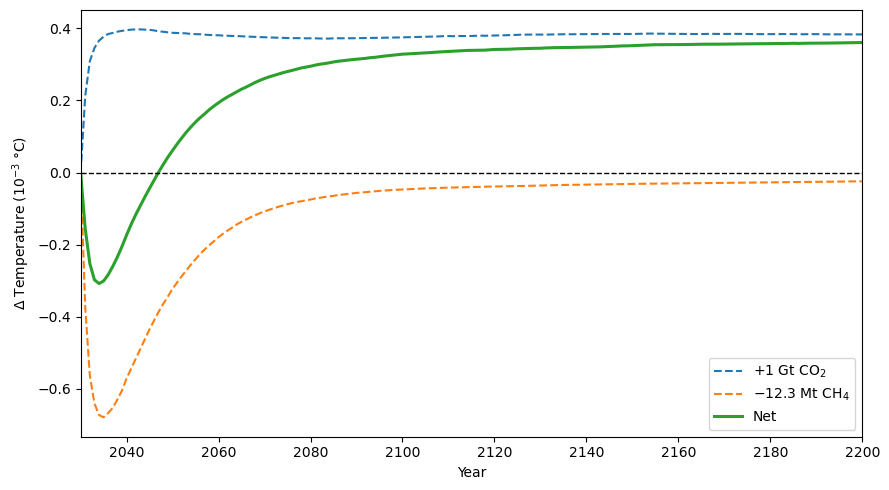

In [116]:
fig, ax = plt.subplots(figsize=(9, 5))

m = plot_years >= PULSE_YEAR
ax.plot(plot_years[m], co2_p50[m] * 1e3, "--", label="+1 Gt CO$_2$")
ax.plot(plot_years[m], ch4_p50[m] * 1e3, "--", label="−12.3 Mt CH$_4$")
ax.plot(plot_years[m], net_p50[m] * 1e3, linewidth=2.2, label="Net")
ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.set_xlim(PULSE_YEAR, 2200)
ax.set_xlabel("Year")
ax.set_ylabel("Δ Temperature ($10^{-3}$ °C)")
ax.legend()
fig.tight_layout()
plt.show()

In [117]:
# ----------------------------
# implied GWP20 and GWP100 from integrated radiative forcing
# ----------------------------

years = np.asarray(f.timebounds, dtype=float)

baseline_F = f.forcing_sum.sel(scenario=BASELINE)
co2_F = f.forcing_sum.sel(scenario="co2_pulse") - baseline_F
ch4_F = f.forcing_sum.sel(scenario="ch4_mitigation") - baseline_F

co2_F_med = co2_F.median("config").values
ch4_F_med = ch4_F.median("config").values

for horizon in [20, 100]:
    mask = (years >= PULSE_YEAR) & (years <= PULSE_YEAR + horizon)

    co2_agwp = np.trapz(co2_F_med[mask], years[mask])
    ch4_agwp = np.trapz(-ch4_F_med[mask], years[mask])

    # pulses are +1 Gt CO2 and -12.3 Mt CH4
    implied_gwp = (ch4_agwp / -CH4_MITIGATION_MT) / (co2_agwp / 1000)

    print(f"GWP{horizon}: {implied_gwp:.2f}")
    print(f"  CO2 integrated forcing: {co2_agwp:.6e} W m-2 yr")
    print(f"  CH4 integrated forcing: {ch4_agwp:.6e} W m-2 yr")

GWP20: 102.47
  CO2 integrated forcing: 1.975360e-02 W m-2 yr
  CH4 integrated forcing: 2.489803e-02 W m-2 yr
GWP100: 32.12
  CO2 integrated forcing: 7.542264e-02 W m-2 yr
  CH4 integrated forcing: 2.980030e-02 W m-2 yr


### Visual reproduction check

Hughes Figure 1 shows, approximately:

- initial cooling after the 2030 pulse
- minimum median cooling around **−0.28 × 10⁻³ °C**
- crossover back through zero around **2046**
- positive warming thereafter
- p05–p95 shading around the median

Those numbers are useful as a visual diagnostic, not hard-coded targets. If this notebook still misses them materially, the next thing to check is the precise FaIR package version and whether Hughes used any additional unpublished preprocessing of the v1.4.0 methane-lifetime configuration.